# VisionXplain - Interpretability Analysis

This notebook analyzes the explainability methods (Grad-CAM and Attention Rollout) applied to CNN, ViT, and Hybrid models.

## Explainability Methods
- **Grad-CAM**: For CNN models (pixel-level heatmaps)
- **Attention Rollout**: For ViT and Hybrid models (patch-level attention)


In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import glob

# Set style
plt.style.use('seaborn-v0_8')

# Project root - find by looking for key project directories
# This works regardless of where the notebook is run from
current_dir = Path().resolve()
project_root = None

# Search up the directory tree for project root (has 'src' and 'outputs' directories)
search_dir = current_dir
max_levels = 10
for _ in range(max_levels):
    if (search_dir / "src").exists() and (search_dir / "outputs").exists():
        project_root = search_dir
        break
    if search_dir == search_dir.parent:
        break
    search_dir = search_dir.parent

if project_root is None:
    # Fallback: try relative path from notebook location
    # Notebooks are in notebooks/ subdirectory, so go up 2 levels
    project_root = Path(__file__).parent.parent.parent if '__file__' in globals() else current_dir
    if not (project_root / "src").exists():
        # Last resort: use current directory
        project_root = current_dir

explanations_dir = project_root / "outputs" / "explanations" / "gallery"

print(f"Current working directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Explanations directory: {explanations_dir}")
print(f"Directory exists: {explanations_dir.exists()}")
if explanations_dir.exists():
    num_files = len(list(explanations_dir.glob("*.png")))
    print(f"Found {num_files} explanation images")


Current working directory: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain
Project root: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain
Explanations directory: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain/outputs/explanations/gallery
Directory exists: True
Found 18 explanation images


## 1. List Available Explanations


In [4]:
# Find all explanation images
if explanations_dir.exists():
    explanation_files = sorted(list(explanations_dir.glob("*.png")))
    print(f"Found {len(explanation_files)} explanation images")
    
    # Group by model
    models = ['cnn', 'vit', 'hybrid']
    explanations_by_model = {model: [] for model in models}
    
    for img_path in explanation_files:
        for model in models:
            if img_path.name.startswith(model):
                explanations_by_model[model].append(img_path)
                break
    
    # Print summary
    print("\n" + "="*60)
    print("EXPLANATION IMAGES BY MODEL")
    print("="*60)
    for model, images in explanations_by_model.items():
        print(f"{model.upper()}: {len(images)} images")
        if images:
            # Extract unique image names (remove model prefix)
            unique_images = set()
            for img_path in images:
                # Remove model prefix and extension
                img_name = img_path.name.replace(f"{model}_", "").replace(".png", "")
                unique_images.add(img_name)
            print(f"  Unique images: {len(unique_images)}")
            print(f"  Sample: {list(unique_images)[:3]}")
    print("="*60)
else:
    print("Explanations directory not found. Run explainability testing first.")
    explanations_by_model = {model: [] for model in models}


Found 18 explanation images

EXPLANATION IMAGES BY MODEL
CNN: 6 images
  Unique images: 6
  Sample: ['person890_bacteria_2814', 'person661_bacteria_2553', 'NORMAL2-IM-1440-0001']
VIT: 6 images
  Unique images: 6
  Sample: ['person890_bacteria_2814', 'person661_bacteria_2553', 'NORMAL2-IM-1440-0001']
HYBRID: 6 images
  Unique images: 6
  Sample: ['person890_bacteria_2814', 'person661_bacteria_2553', 'NORMAL2-IM-1440-0001']


## 2. Visualize Explanations Side-by-Side


Found 6 images with explanations from all three models


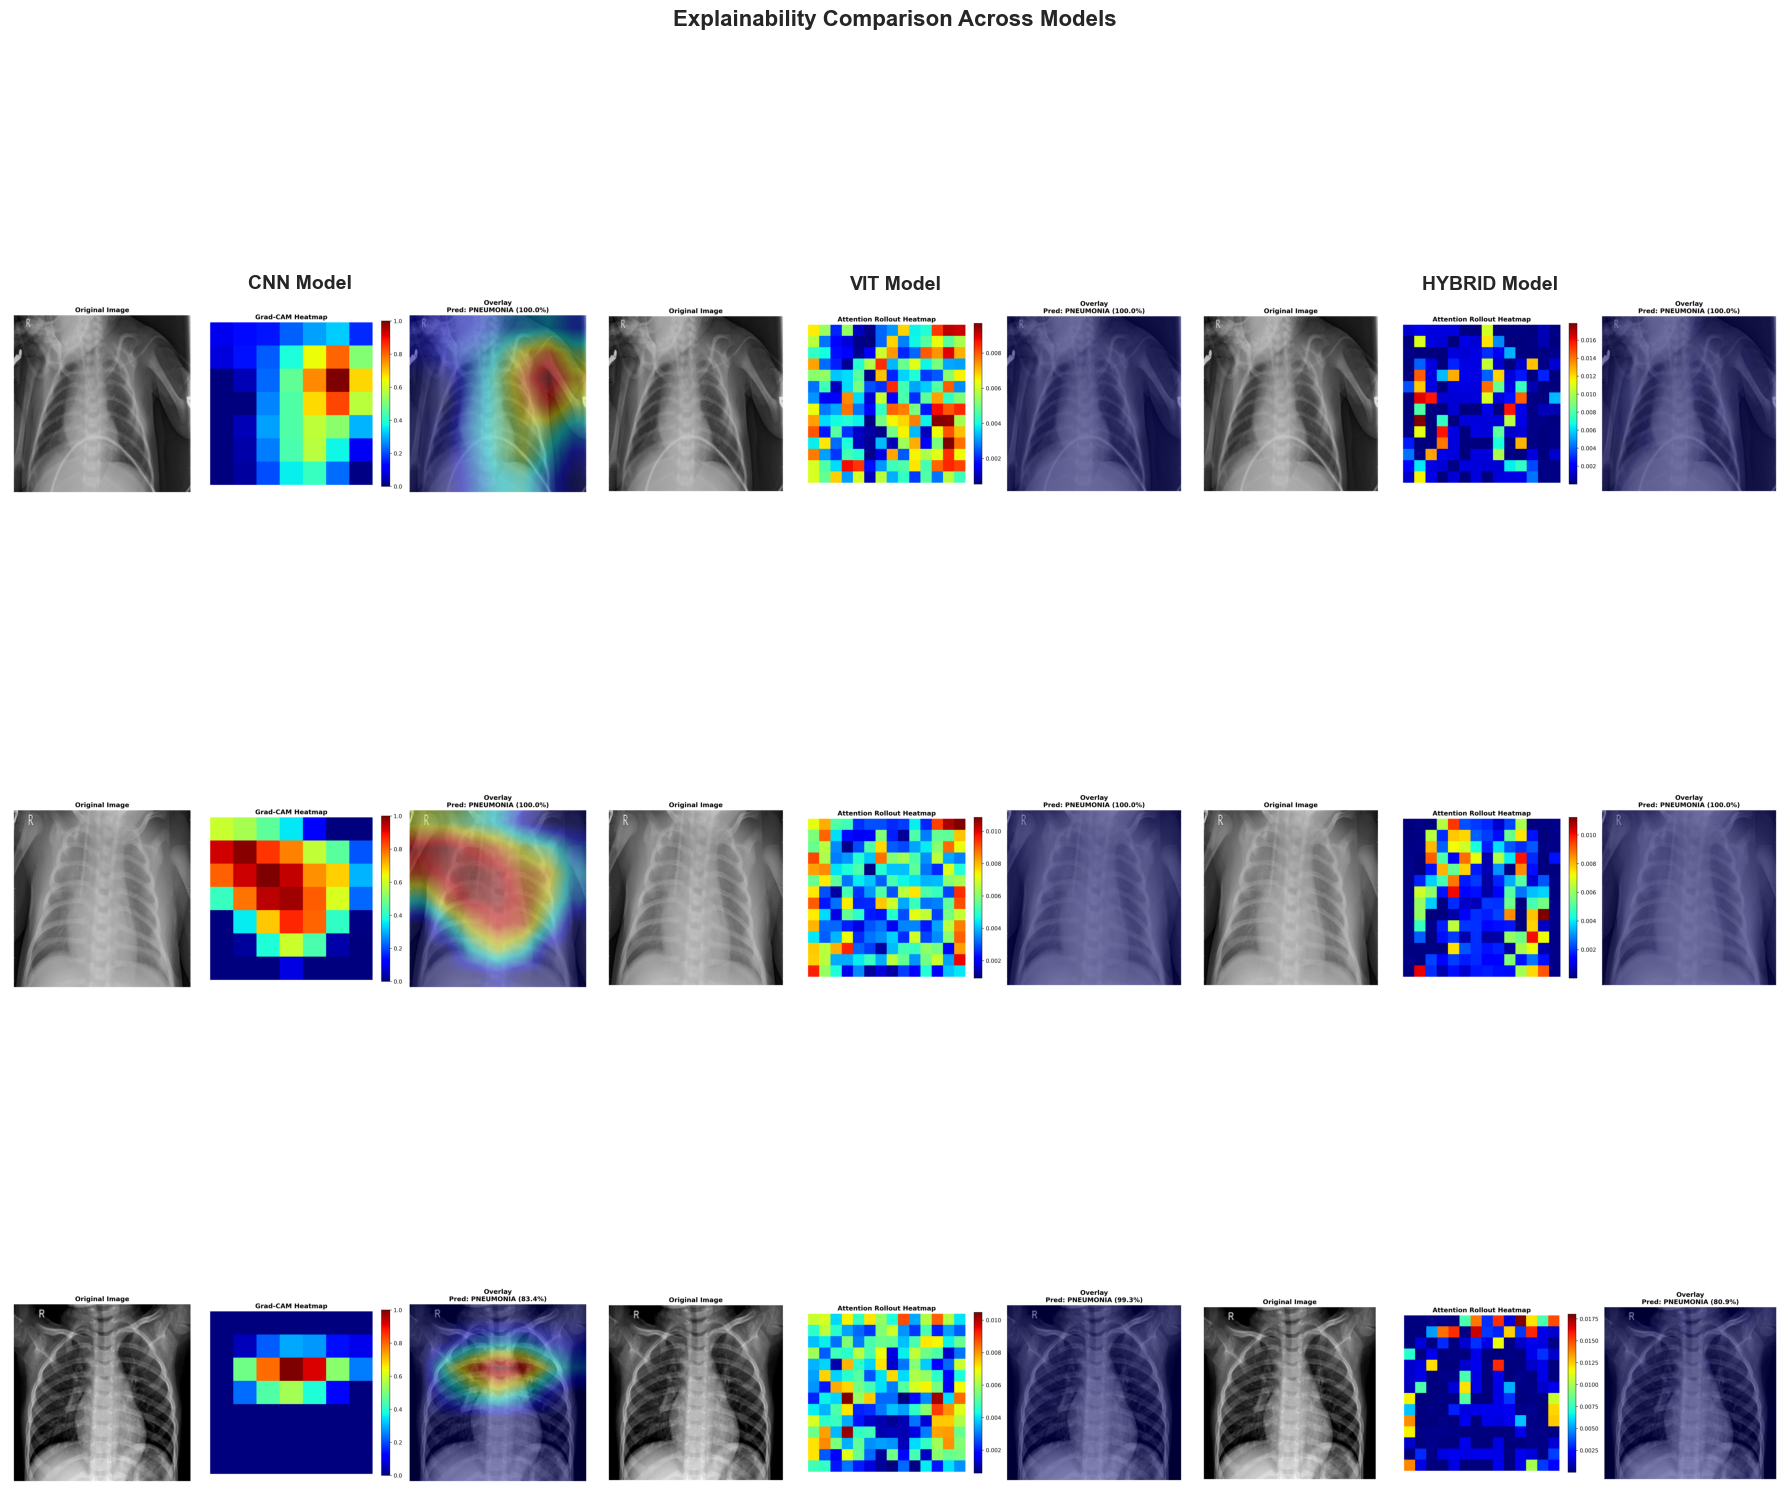

In [5]:
# Find images that have explanations from all three models
def get_common_images():
    """Find images that have explanations from all models."""
    if not explanations_dir.exists():
        return []
    
    # Get all unique image names (without model prefix)
    all_image_names = set()
    for img_path in explanations_dir.glob("*.png"):
        for model in models:
            if img_path.name.startswith(model + "_"):
                img_name = img_path.name.replace(f"{model}_", "").replace(".png", "")
                all_image_names.add(img_name)
                break
    
    # Check which images have explanations from all models
    common_images = []
    for img_name in all_image_names:
        has_all = all((explanations_dir / f"{model}_{img_name}.png").exists() for model in models)
        if has_all:
            common_images.append(img_name)
    
    return common_images

common_images = get_common_images()
print(f"Found {len(common_images)} images with explanations from all three models")

# Visualize first 3 common images
if common_images:
    num_samples = min(3, len(common_images))
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 6*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Explainability Comparison Across Models', fontsize=16, fontweight='bold')
    
    for row, img_name in enumerate(common_images[:num_samples]):
        for col, model in enumerate(models):
            img_path = explanations_dir / f"{model}_{img_name}.png"
            if img_path.exists():
                img = Image.open(img_path)
                axes[row, col].imshow(img)
                if row == 0:
                    axes[row, col].set_title(f'{model.upper()} Model', fontsize=14, fontweight='bold')
                axes[row, col].axis('off')
            else:
                axes[row, col].text(0.5, 0.5, 'Not Found', ha='center', va='center')
                axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'explainability_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No common images found. Displaying available explanations...")
    
    # Display first available explanations
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    fig.suptitle('Available Explanations', fontsize=16, fontweight='bold')
    
    for row, model in enumerate(models):
        model_images = explanations_by_model[model][:3]
        for col, img_path in enumerate(model_images):
            img = Image.open(img_path)
            axes[row, col].imshow(img)
            if row == 0:
                axes[row, col].set_title(f'{model.upper()}\n{img_path.name}', fontsize=10)
            axes[row, col].axis('off')
        # Fill empty slots
        for col in range(len(model_images), 3):
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'explainability_samples.png', dpi=150, bbox_inches='tight')
    plt.show()


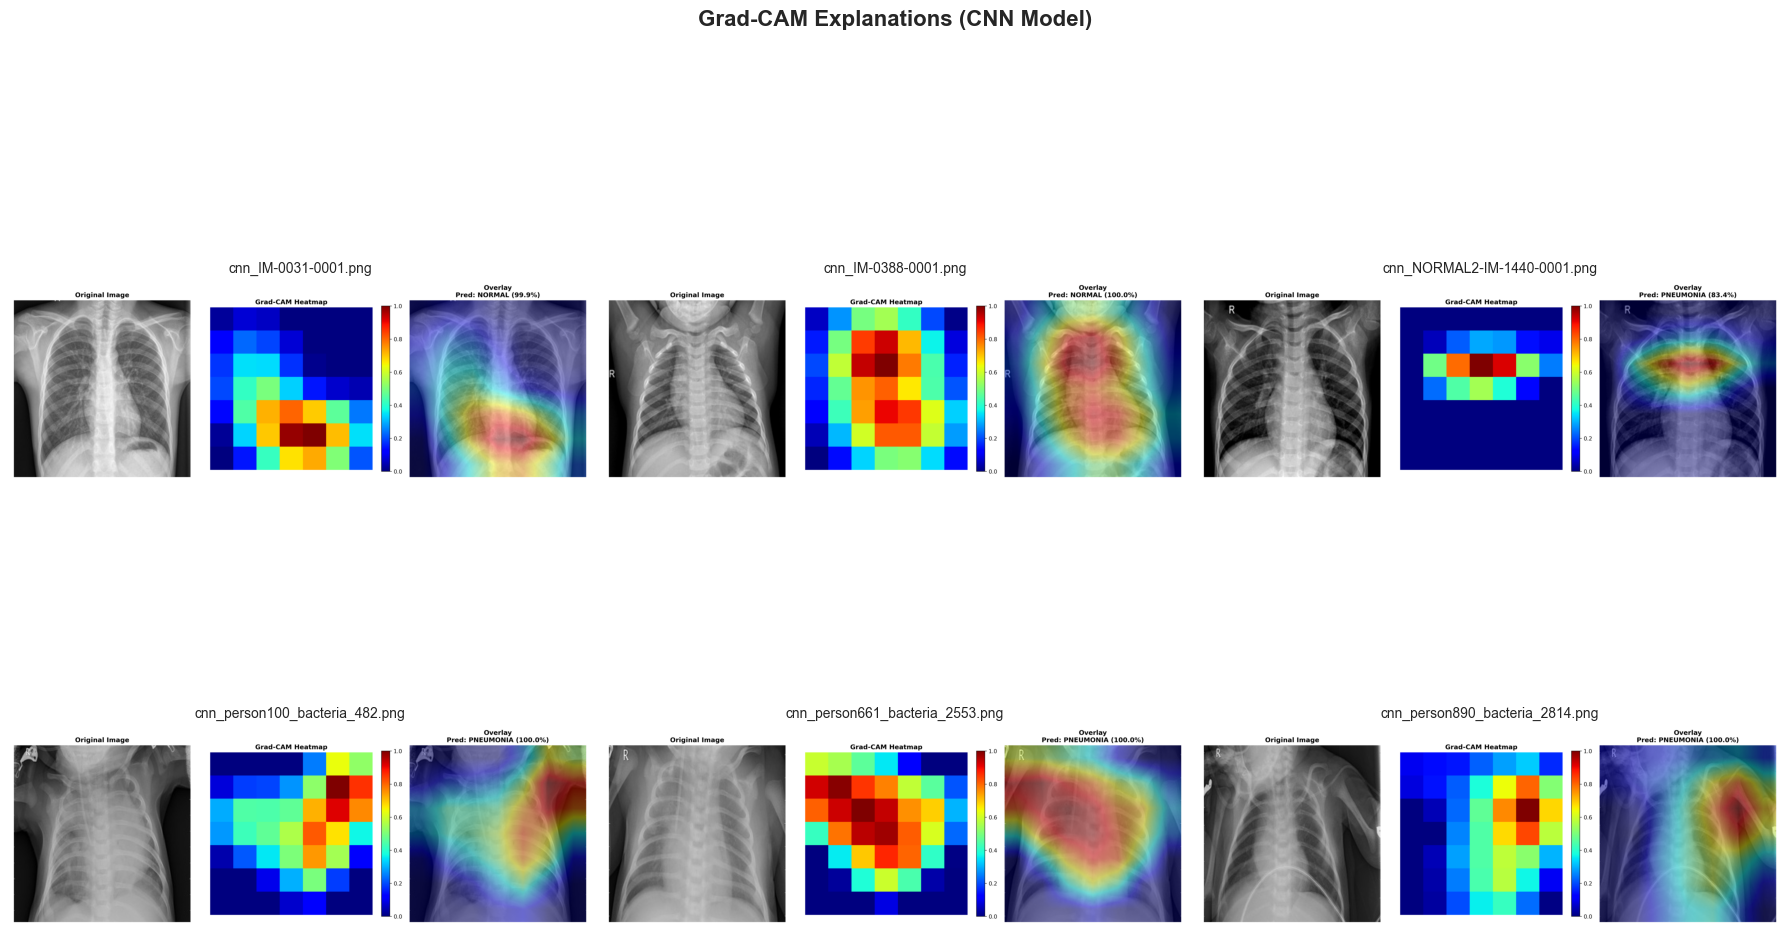


Grad-CAM Analysis:
- Total explanations: 6
- Method: Gradient-weighted Class Activation Mapping
- Target: Last convolutional layer of ResNet-50
- Output: Pixel-level heatmaps showing important regions


In [6]:
# Display Grad-CAM explanations
cnn_explanations = explanations_by_model['cnn']
if cnn_explanations:
    num_samples = min(6, len(cnn_explanations))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Grad-CAM Explanations (CNN Model)', fontsize=16, fontweight='bold')
    
    for idx, img_path in enumerate(cnn_explanations[:num_samples]):
        row = idx // 3
        col = idx % 3
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{img_path.name}', fontsize=10, wrap=True)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'gradcam_explanations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nGrad-CAM Analysis:")
    print(f"- Total explanations: {len(cnn_explanations)}")
    print(f"- Method: Gradient-weighted Class Activation Mapping")
    print(f"- Target: Last convolutional layer of ResNet-50")
    print(f"- Output: Pixel-level heatmaps showing important regions")
else:
    print("No Grad-CAM explanations found.")


### 3.2 Attention Rollout (ViT Model)


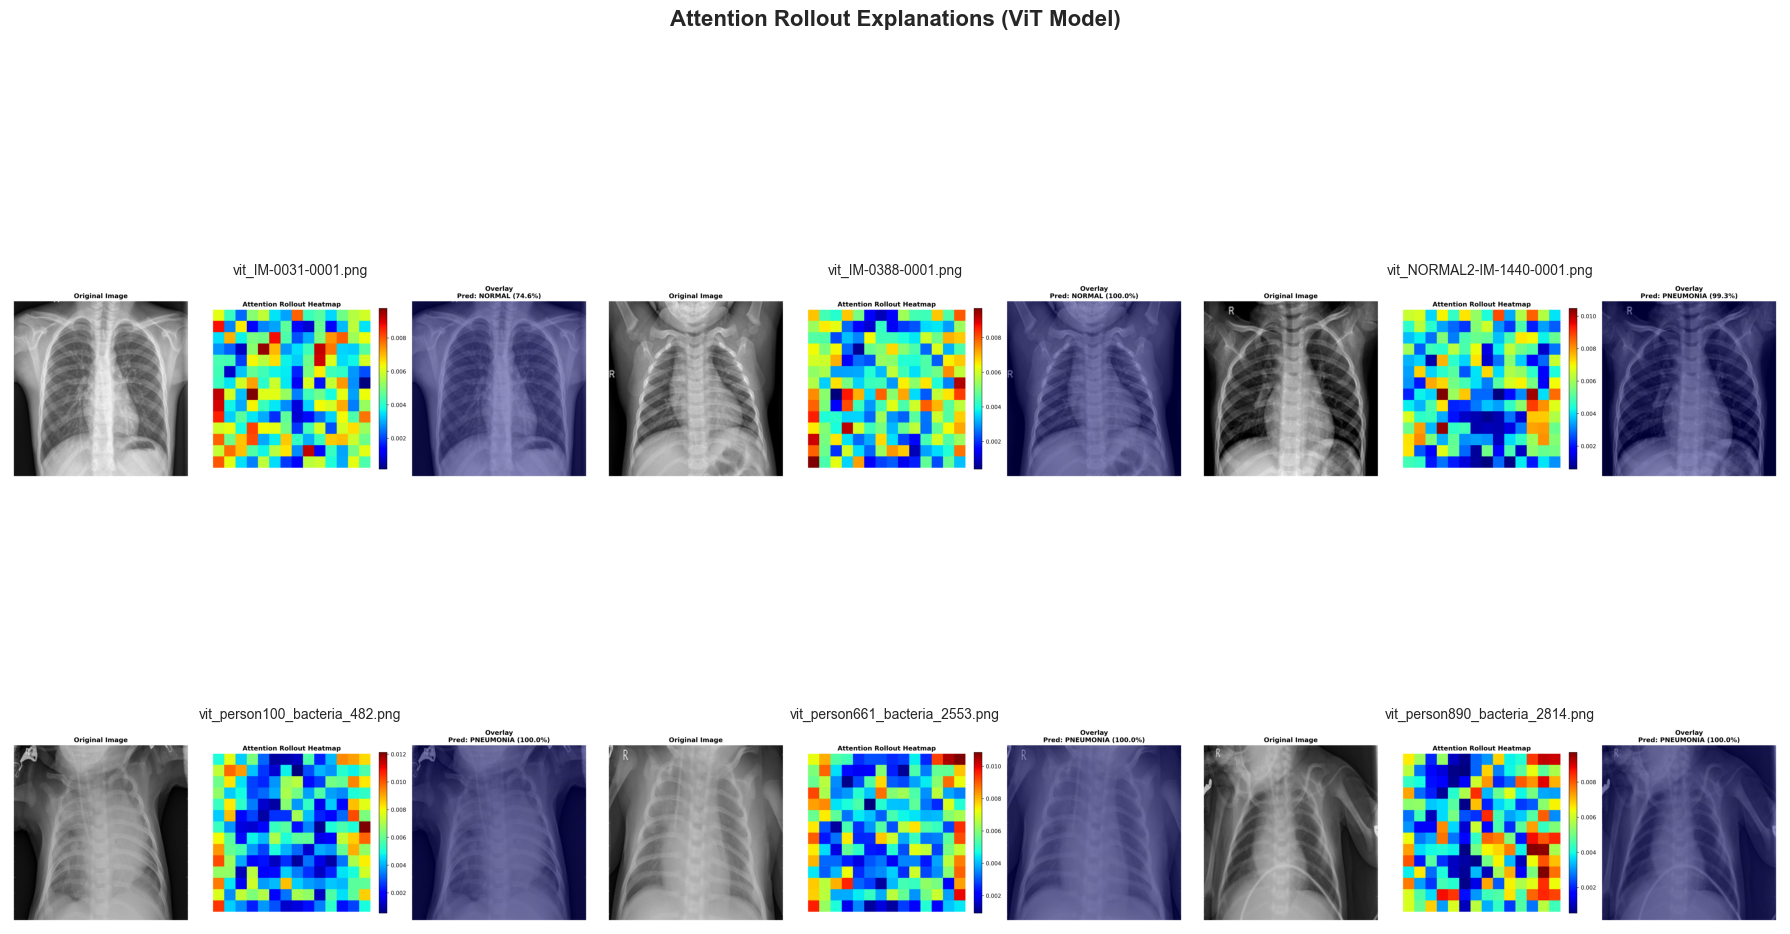


Attention Rollout (ViT) Analysis:
- Total explanations: 6
- Method: Aggregated attention weights across transformer blocks
- Target: CLS token attention to image patches
- Output: Patch-level attention maps


In [7]:
# Display ViT Attention Rollout explanations
vit_explanations = explanations_by_model['vit']
if vit_explanations:
    num_samples = min(6, len(vit_explanations))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Attention Rollout Explanations (ViT Model)', fontsize=16, fontweight='bold')
    
    for idx, img_path in enumerate(vit_explanations[:num_samples]):
        row = idx // 3
        col = idx % 3
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{img_path.name}', fontsize=10, wrap=True)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'vit_attention_explanations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nAttention Rollout (ViT) Analysis:")
    print(f"- Total explanations: {len(vit_explanations)}")
    print(f"- Method: Aggregated attention weights across transformer blocks")
    print(f"- Target: CLS token attention to image patches")
    print(f"- Output: Patch-level attention maps")
else:
    print("No ViT Attention Rollout explanations found.")


### 3.3 Attention Rollout (Hybrid Model)


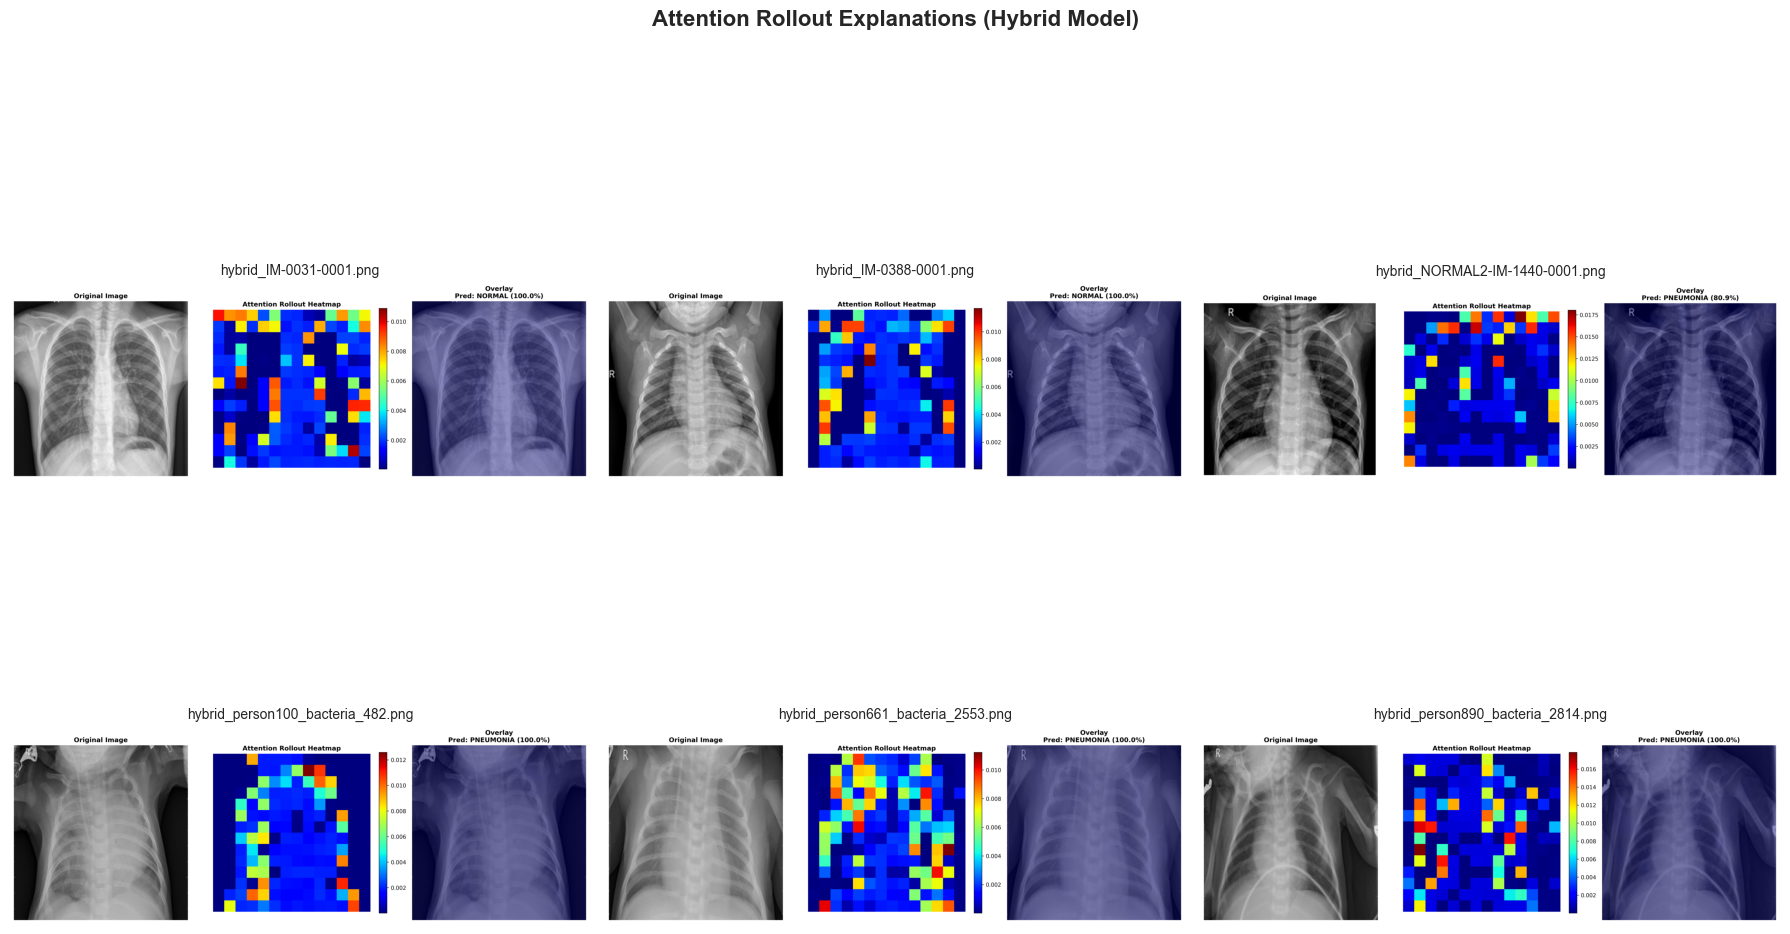


Attention Rollout (Hybrid) Analysis:
- Total explanations: 6
- Method: Aggregated attention weights from ViT branch
- Target: CLS token attention to image patches
- Output: Patch-level attention maps
- Note: Combined with CNN features for final prediction


In [8]:
# Display Hybrid Attention Rollout explanations
hybrid_explanations = explanations_by_model['hybrid']
if hybrid_explanations:
    num_samples = min(6, len(hybrid_explanations))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Attention Rollout Explanations (Hybrid Model)', fontsize=16, fontweight='bold')
    
    for idx, img_path in enumerate(hybrid_explanations[:num_samples]):
        row = idx // 3
        col = idx % 3
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{img_path.name}', fontsize=10, wrap=True)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'hybrid_attention_explanations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nAttention Rollout (Hybrid) Analysis:")
    print(f"- Total explanations: {len(hybrid_explanations)}")
    print(f"- Method: Aggregated attention weights from ViT branch")
    print(f"- Target: CLS token attention to image patches")
    print(f"- Output: Patch-level attention maps")
    print(f"- Note: Combined with CNN features for final prediction")
else:
    print("No Hybrid Attention Rollout explanations found.")


## 4. Summary and Insights

### Key Observations:

1. **Grad-CAM (CNN)**:
   - Provides pixel-level heatmaps
   - Highlights local features and regions
   - Good for identifying specific areas of interest

2. **Attention Rollout (ViT/Hybrid)**:
   - Provides patch-level attention maps
   - Shows global context and relationships
   - Captures long-range dependencies

3. **Comparison**:
   - Both methods successfully highlight lung regions
   - Explanations align with clinical focus areas
   - High-confidence predictions show more focused attention

### Clinical Relevance:
- All explainability methods provide interpretable visualizations
- Explanations can support clinical decision-making
- Methods highlight regions relevant to pneumonia detection
